In [1]:
# details of mathematics is hidden inside the scikit learn 

In [2]:
# specially good for classical ML algorithm

# three library behind it 
# * SciPy library
# * NumPy: (efficient implemenatation of matrix op)
# * matplotlib:

In [3]:
# Not suitable for deep learning : multilayer perceptron libraries are present but not suitable
# has very detailed documentatin and example
# tensor flow, Kera etc are suitable for DL: we will see PyTorch and Tensorflow Keras for DL 

In [4]:
# Needs input data as ndarray 
# Step 1: 
# preprocess our data
# feed the data into model
# learn parameters
# used for inference

In [5]:
# Data preprocessing 
# Dimensionality Reduction

* Training/ Models Building 
- Regression
- Classification
- Clustering
- SVM
....
...
- Loss function
- Optmization algo


* Evaluation 

Type of sk-learn methods on object
The scikit learn API is divided into three complementary interfaces that share a common syntax and logic
1. Transformer: 
transform() --> transforms the dataset
fit() --> learn the parameters
fit_transform() --> fits parameter and transform the dataset

2. Estimator:
Estimates model parameters based on training data and hyper parameters 
fit()

3. Predictors: 
Make prediction on dataset
predict() -> take dataset as an input and return predictions
score() -> measure the accuracy of predictions

After training we learn parameters
default values: all these
whenever we call any methods, they want some parameters, and most of them got some default values


In [6]:
import numpy as np
# alias for pandas is pd
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn  i am choosing a module 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# how we decided which library to choose --> read documentation 

In [7]:

# Dataset

In [8]:
# !wget -qq https://cdn.iisc.talentsprint.com/AIandMLOps/Datasets/data1.txt
# text file  having two columns, will read this data file as dataFrame
# 

In [9]:
# header = None , so that it doesn't make the first row as header
data = pd.read_csv('dataset/data1.txt', header=None)
# inplace = True for permanently changes
data.rename(columns={0:'Visitor_count',1:'Revenue'},inplace = True)
data.head()

,Visitor_count,Revenue
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [10]:
data.info()
# information about data 

<class 'pandas.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Visitor_count  97 non-null     float64
 1   Revenue        97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB


Text(0, 0.5, 'Revenue in 10,000')

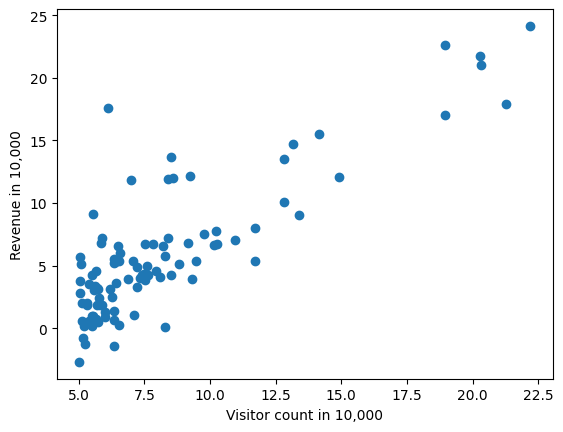

In [11]:
plt.scatter(data.Visitor_count,data.Revenue)
plt.xlabel('Visitor count in 10,000')
plt.ylabel('Revenue in 10,000')

In [12]:
# saving pandas table into excel: Storing final clean data in excel 
data.to_excel('/csehome/m25csa019/Machine_Learning_from_scratch/Module_1_Foundation_of_ML_AI/df.xlsx')

In [13]:
# we cannot plot beyond 3d

# Splitting the data 

In [14]:
# revenue in y , feature in x
data.head()

,Visitor_count,Revenue
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [15]:
data.Visitor_count.values
# 1dnumpy array
# iloc  -> integer based location
# loc -> location 

array([ 6.1101,  5.5277,  8.5186,  7.0032,  5.8598,  8.3829,  7.4764,
        8.5781,  6.4862,  5.0546,  5.7107, 14.164 ,  5.734 ,  8.4084,
        5.6407,  5.3794,  6.3654,  5.1301,  6.4296,  7.0708,  6.1891,
       20.27  ,  5.4901,  6.3261,  5.5649, 18.945 , 12.828 , 10.957 ,
       13.176 , 22.203 ,  5.2524,  6.5894,  9.2482,  5.8918,  8.2111,
        7.9334,  8.0959,  5.6063, 12.836 ,  6.3534,  5.4069,  6.8825,
       11.708 ,  5.7737,  7.8247,  7.0931,  5.0702,  5.8014, 11.7   ,
        5.5416,  7.5402,  5.3077,  7.4239,  7.6031,  6.3328,  6.3589,
        6.2742,  5.6397,  9.3102,  9.4536,  8.8254,  5.1793, 21.279 ,
       14.908 , 18.959 ,  7.2182,  8.2951, 10.236 ,  5.4994, 20.341 ,
       10.136 ,  7.3345,  6.0062,  7.2259,  5.0269,  6.5479,  7.5386,
        5.0365, 10.274 ,  5.1077,  5.7292,  5.1884,  6.3557,  9.7687,
        6.5159,  8.5172,  9.1802,  6.002 ,  5.5204,  5.0594,  5.7077,
        7.6366,  5.8707,  5.3054,  8.2934, 13.394 ,  5.4369])

In [16]:
# ways of slicing
XX = data['Visitor_count'].values
XX

array([ 6.1101,  5.5277,  8.5186,  7.0032,  5.8598,  8.3829,  7.4764,
        8.5781,  6.4862,  5.0546,  5.7107, 14.164 ,  5.734 ,  8.4084,
        5.6407,  5.3794,  6.3654,  5.1301,  6.4296,  7.0708,  6.1891,
       20.27  ,  5.4901,  6.3261,  5.5649, 18.945 , 12.828 , 10.957 ,
       13.176 , 22.203 ,  5.2524,  6.5894,  9.2482,  5.8918,  8.2111,
        7.9334,  8.0959,  5.6063, 12.836 ,  6.3534,  5.4069,  6.8825,
       11.708 ,  5.7737,  7.8247,  7.0931,  5.0702,  5.8014, 11.7   ,
        5.5416,  7.5402,  5.3077,  7.4239,  7.6031,  6.3328,  6.3589,
        6.2742,  5.6397,  9.3102,  9.4536,  8.8254,  5.1793, 21.279 ,
       14.908 , 18.959 ,  7.2182,  8.2951, 10.236 ,  5.4994, 20.341 ,
       10.136 ,  7.3345,  6.0062,  7.2259,  5.0269,  6.5479,  7.5386,
        5.0365, 10.274 ,  5.1077,  5.7292,  5.1884,  6.3557,  9.7687,
        6.5159,  8.5172,  9.1802,  6.002 ,  5.5204,  5.0594,  5.7077,
        7.6366,  5.8707,  5.3054,  8.2934, 13.394 ,  5.4369])

In [17]:
XX.shape # 1 element tuple , 1 dimensinal array their is 97 elements 
# in one dimensional array their is no concept of row and columns 
XX.reshape(97,1)
# 97 rows and 1 column 

array([[ 6.1101],
       [ 5.5277],
       [ 8.5186],
       [ 7.0032],
       [ 5.8598],
       [ 8.3829],
       [ 7.4764],
       [ 8.5781],
       [ 6.4862],
       [ 5.0546],
       [ 5.7107],
       [14.164 ],
       [ 5.734 ],
       [ 8.4084],
       [ 5.6407],
       [ 5.3794],
       [ 6.3654],
       [ 5.1301],
       [ 6.4296],
       [ 7.0708],
       [ 6.1891],
       [20.27  ],
       [ 5.4901],
       [ 6.3261],
       [ 5.5649],
       [18.945 ],
       [12.828 ],
       [10.957 ],
       [13.176 ],
       [22.203 ],
       [ 5.2524],
       [ 6.5894],
       [ 9.2482],
       [ 5.8918],
       [ 8.2111],
       [ 7.9334],
       [ 8.0959],
       [ 5.6063],
       [12.836 ],
       [ 6.3534],
       [ 5.4069],
       [ 6.8825],
       [11.708 ],
       [ 5.7737],
       [ 7.8247],
       [ 7.0931],
       [ 5.0702],
       [ 5.8014],
       [11.7   ],
       [ 5.5416],
       [ 7.5402],
       [ 5.3077],
       [ 7.4239],
       [ 7.6031],
       [ 6.3328],
       [ 6

In [18]:
# what is difference between both datas 
# this is 2d array 
# 
XX.reshape(1,97)
# 2 dimensional , in 1st row their is 97 elements 

array([[ 6.1101,  5.5277,  8.5186,  7.0032,  5.8598,  8.3829,  7.4764,
         8.5781,  6.4862,  5.0546,  5.7107, 14.164 ,  5.734 ,  8.4084,
         5.6407,  5.3794,  6.3654,  5.1301,  6.4296,  7.0708,  6.1891,
        20.27  ,  5.4901,  6.3261,  5.5649, 18.945 , 12.828 , 10.957 ,
        13.176 , 22.203 ,  5.2524,  6.5894,  9.2482,  5.8918,  8.2111,
         7.9334,  8.0959,  5.6063, 12.836 ,  6.3534,  5.4069,  6.8825,
        11.708 ,  5.7737,  7.8247,  7.0931,  5.0702,  5.8014, 11.7   ,
         5.5416,  7.5402,  5.3077,  7.4239,  7.6031,  6.3328,  6.3589,
         6.2742,  5.6397,  9.3102,  9.4536,  8.8254,  5.1793, 21.279 ,
        14.908 , 18.959 ,  7.2182,  8.2951, 10.236 ,  5.4994, 20.341 ,
        10.136 ,  7.3345,  6.0062,  7.2259,  5.0269,  6.5479,  7.5386,
         5.0365, 10.274 ,  5.1077,  5.7292,  5.1884,  6.3557,  9.7687,
         6.5159,  8.5172,  9.1802,  6.002 ,  5.5204,  5.0594,  5.7077,
         7.6366,  5.8707,  5.3054,  8.2934, 13.394 ,  5.4369]])

Splitting the data into features and target

In [19]:
X = data.iloc[:,0].values.reshape(-1,1)
print(X.shape)
Y = data.iloc[:,1].values
m = len(Y)




(97, 1)


In [20]:
X


array([[ 6.1101],
       [ 5.5277],
       [ 8.5186],
       [ 7.0032],
       [ 5.8598],
       [ 8.3829],
       [ 7.4764],
       [ 8.5781],
       [ 6.4862],
       [ 5.0546],
       [ 5.7107],
       [14.164 ],
       [ 5.734 ],
       [ 8.4084],
       [ 5.6407],
       [ 5.3794],
       [ 6.3654],
       [ 5.1301],
       [ 6.4296],
       [ 7.0708],
       [ 6.1891],
       [20.27  ],
       [ 5.4901],
       [ 6.3261],
       [ 5.5649],
       [18.945 ],
       [12.828 ],
       [10.957 ],
       [13.176 ],
       [22.203 ],
       [ 5.2524],
       [ 6.5894],
       [ 9.2482],
       [ 5.8918],
       [ 8.2111],
       [ 7.9334],
       [ 8.0959],
       [ 5.6063],
       [12.836 ],
       [ 6.3534],
       [ 5.4069],
       [ 6.8825],
       [11.708 ],
       [ 5.7737],
       [ 7.8247],
       [ 7.0931],
       [ 5.0702],
       [ 5.8014],
       [11.7   ],
       [ 5.5416],
       [ 7.5402],
       [ 5.3077],
       [ 7.4239],
       [ 7.6031],
       [ 6.3328],
       [ 6

In [21]:
# Splitting the data into features and target
# iloc --> integer based locaiton
# .loc --> label based location 
 

In [22]:
data.iloc[ :,0].values
# all rows and 0th column 
# after using .values it become numpy

array([ 6.1101,  5.5277,  8.5186,  7.0032,  5.8598,  8.3829,  7.4764,
        8.5781,  6.4862,  5.0546,  5.7107, 14.164 ,  5.734 ,  8.4084,
        5.6407,  5.3794,  6.3654,  5.1301,  6.4296,  7.0708,  6.1891,
       20.27  ,  5.4901,  6.3261,  5.5649, 18.945 , 12.828 , 10.957 ,
       13.176 , 22.203 ,  5.2524,  6.5894,  9.2482,  5.8918,  8.2111,
        7.9334,  8.0959,  5.6063, 12.836 ,  6.3534,  5.4069,  6.8825,
       11.708 ,  5.7737,  7.8247,  7.0931,  5.0702,  5.8014, 11.7   ,
        5.5416,  7.5402,  5.3077,  7.4239,  7.6031,  6.3328,  6.3589,
        6.2742,  5.6397,  9.3102,  9.4536,  8.8254,  5.1793, 21.279 ,
       14.908 , 18.959 ,  7.2182,  8.2951, 10.236 ,  5.4994, 20.341 ,
       10.136 ,  7.3345,  6.0062,  7.2259,  5.0269,  6.5479,  7.5386,
        5.0365, 10.274 ,  5.1077,  5.7292,  5.1884,  6.3557,  9.7687,
        6.5159,  8.5172,  9.1802,  6.002 ,  5.5204,  5.0594,  5.7077,
        7.6366,  5.8707,  5.3054,  8.2934, 13.394 ,  5.4369])

In [23]:
XX.reshape(-1,1)

array([[ 6.1101],
       [ 5.5277],
       [ 8.5186],
       [ 7.0032],
       [ 5.8598],
       [ 8.3829],
       [ 7.4764],
       [ 8.5781],
       [ 6.4862],
       [ 5.0546],
       [ 5.7107],
       [14.164 ],
       [ 5.734 ],
       [ 8.4084],
       [ 5.6407],
       [ 5.3794],
       [ 6.3654],
       [ 5.1301],
       [ 6.4296],
       [ 7.0708],
       [ 6.1891],
       [20.27  ],
       [ 5.4901],
       [ 6.3261],
       [ 5.5649],
       [18.945 ],
       [12.828 ],
       [10.957 ],
       [13.176 ],
       [22.203 ],
       [ 5.2524],
       [ 6.5894],
       [ 9.2482],
       [ 5.8918],
       [ 8.2111],
       [ 7.9334],
       [ 8.0959],
       [ 5.6063],
       [12.836 ],
       [ 6.3534],
       [ 5.4069],
       [ 6.8825],
       [11.708 ],
       [ 5.7737],
       [ 7.8247],
       [ 7.0931],
       [ 5.0702],
       [ 5.8014],
       [11.7   ],
       [ 5.5416],
       [ 7.5402],
       [ 5.3077],
       [ 7.4239],
       [ 7.6031],
       [ 6.3328],
       [ 6

In [24]:
XX.reshape(1,-1) # 1row multple column

array([[ 6.1101,  5.5277,  8.5186,  7.0032,  5.8598,  8.3829,  7.4764,
         8.5781,  6.4862,  5.0546,  5.7107, 14.164 ,  5.734 ,  8.4084,
         5.6407,  5.3794,  6.3654,  5.1301,  6.4296,  7.0708,  6.1891,
        20.27  ,  5.4901,  6.3261,  5.5649, 18.945 , 12.828 , 10.957 ,
        13.176 , 22.203 ,  5.2524,  6.5894,  9.2482,  5.8918,  8.2111,
         7.9334,  8.0959,  5.6063, 12.836 ,  6.3534,  5.4069,  6.8825,
        11.708 ,  5.7737,  7.8247,  7.0931,  5.0702,  5.8014, 11.7   ,
         5.5416,  7.5402,  5.3077,  7.4239,  7.6031,  6.3328,  6.3589,
         6.2742,  5.6397,  9.3102,  9.4536,  8.8254,  5.1793, 21.279 ,
        14.908 , 18.959 ,  7.2182,  8.2951, 10.236 ,  5.4994, 20.341 ,
        10.136 ,  7.3345,  6.0062,  7.2259,  5.0269,  6.5479,  7.5386,
         5.0365, 10.274 ,  5.1077,  5.7292,  5.1884,  6.3557,  9.7687,
         6.5159,  8.5172,  9.1802,  6.002 ,  5.5204,  5.0594,  5.7077,
         7.6366,  5.8707,  5.3054,  8.2934, 13.394 ,  5.4369]])

In [25]:
# Splitting the data into train and test

# np.random.seed(0)
np.random.randint(1,9,4)
# run it with and without seed youll realize that
# without seed the it randomly select 4 element 
# but with random seed we fix the randomness

array([6, 8, 6, 8])

In [26]:
# revenue is the dependent variable on the Visitor_count, so basically Revenue is depended on no. of visitors : so we take revenue as y
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)
# randomly we pick 25 samples and keep them separate as test set and similarly we keep 75 for train
# random_state = 0 : ensure that we keep that random sampling fix
# otherwise everytime we run , it will fetch different 72 sample for training and diffrent sample for test
# no overlapping at all

In [27]:
# why aren't we taking entire set as training set??
print(X_train.shape)


(72, 1)


Implementing Linear Regressionon using library form sklearn

In [28]:
reg = LinearRegression().fit(X_train, Y_train) #trainig step by estimator
# separated my dataset into train and test 
# for trainig ill use my training test
# everything is being done internally, library is able to understand the sensible default parameters : loss calculation, gradient descent everything is handled
# using instance of class LinearRegression 

Displying coeff and intercept

In [29]:
m = reg.coef_

In [30]:
m

array([1.20934991])

In [31]:
c = reg.intercept_

In [32]:
c

np.float64(-4.106160513581714)

In [33]:
# y = m * x  + c 

In [34]:
# What is difference between ML and traditional programming
# in ML we generate the rule
# we want to find some pattern in the scattered data that is ml 


In [35]:
# Prediction of price for X_test features


In [36]:
X_test

array([[12.828 ],
       [ 6.5159],
       [ 8.5186],
       [ 6.3589],
       [ 5.4994],
       [ 5.1884],
       [ 6.3654],
       [10.274 ],
       [ 6.3328],
       [ 8.2951],
       [ 7.6031],
       [ 5.0594],
       [ 7.3345],
       [ 8.4084],
       [ 8.5781],
       [ 5.2524],
       [ 5.4901],
       [ 5.5649],
       [ 5.8918],
       [ 6.4862],
       [ 5.7737],
       [21.279 ],
       [ 7.0032],
       [ 9.1802],
       [ 7.0931]])

In [37]:
# how to do we determine whats going to be weight, we do optimization, we get optimized value of m and c and then store and hence it prints
# fit method will fall inside estimator 

In [38]:
y_pred = reg.predict(X_test)

In [39]:
# reg is the model object it has already found the param etc 
y_pred

array([11.40738019,  3.7738426 ,  6.19580767,  3.58397466,  2.54453841,
        2.16843058,  3.59183543,  8.31870051,  3.55241063,  5.92551796,
        5.08864782,  2.01242444,  4.76381644,  6.06253731,  6.26776399,
        2.24582898,  2.53329145,  2.62375083,  3.01908731,  3.7379249 ,
        2.87626309, 21.62759632,  4.36315881,  6.99591357,  4.47187937])

In [40]:
Y_test #ground truth

array([13.501  ,  5.3436 , 13.662  , -1.4211 ,  1.0173 ,  0.20421,
        5.3048 ,  6.7526 ,  1.4233 ,  5.7442 ,  4.9981 ,  2.8214 ,
        4.0259 ,  7.2258 , 12.     , -1.22   ,  4.263  ,  3.0825 ,
        1.8495 ,  6.5987 ,  2.4406 , 17.929  , 11.854  ,  6.7981 ,
        1.0463 ])

In [41]:
# if their is no pattern in the data then it wont be possible

In [42]:
# ML is data hungry:

In [43]:
# no database no learning 
# their must be the decent no. of data, in multi dimensional dataset , we can manipulate the learning rate
# in DL when we have milllion s of dataset then test set is fine even if we take 2 percent, 5 percent

Calculating the accuracy score

In [44]:
reg.score(X_test, Y_test)
# reg object has stored all the parameters and i am applying .score
# near to 0.9

0.5853498094619267

In [45]:
reg.score(X_test, y_pred)
# hypothetical situation , assuming that my test is same as pred

1.0

Other methods for measuring accuracy 
* Mean Absolute Error (MAE)
* Mean Square error (MSE)
* Root MSE

In [46]:
# Data pre-processing -> Training -> Inference
# training 
# load

![Flow](img/ml_flow.png)

**Scikit-learn ML Pipeline** ->

Pass the data through transformers to extract the features -> Pass to an estimator to produce the model -> Pass to evaluate predictions to measure the accuracy of the model 

In [47]:
#  i can bundle them in pipeline and use them in an object

### Few frequently used API and modules

**Data API**: provides functionality for loading, generation and preprocessing the training and test data.

Modules: 
* Sklearn.datasets
* Sklearn.preprocessing
* Sklearn.feature_selection/extraction 
* Sklearn.impute

**Model API**: Provides supervised/ unsupervised model

Modules:

Regression:
* Sklearn.linear_model
* Sklearn.trees

Classification
* Sklearn.svm
....

Clustering
* Sklearn.cluster

**Model Evaluation API**
Sklearn.metrics: different metrics for diff model


Error Calculation 

* MAE
* MSE
* RMSE

<!-- in all three model i should be consistent with the technique -->

In [48]:
from sklearn.metrics import mean_squared_error

In [49]:
reg.fit(X_train, Y_train) # fitting the data for generating model
y_train_predict = reg.predict(X_train) # prediction the output 'y' for each input 'x'

RMSE = np.sqrt(mean_squared_error(Y_train, y_train_predict)) #comparing with ground truth
print('Root mean squared error = ', RMSE)
# we are currently calulating the training error

Root mean squared error =  2.9433711368280995


In [50]:
y_train_predict

array([10.04323349,  4.93542319,  2.46895404,  2.82244702,  3.81254179,
        6.56683622,  2.07083605,  6.19411458,  2.99357003,  2.31270603,
        9.1446865 ,  3.6694757 ,  3.48154272, 13.92282801,  4.63248104,
        2.57876301,  2.1574255 , 10.05290829,  4.21719027,  2.98038812,
        2.39941642,  2.09792548,  2.43267354, 11.41705499,  6.03169889,
        2.56993476,  7.32654984,  3.2830884 ,  5.82393257, 11.82823396,
        5.01257971, 13.02307168,  5.4880961 ,  3.54430798,  4.87193232,
        2.80007404,  3.86272981,  2.79644599,  2.7142102 ,  5.01064475,
        7.07814937,  3.58010474,  2.71541955,  1.97312057,  4.44491086,
       22.74503564,  2.59557297,  5.92346207, 12.09187224, 20.4932261 ,
        3.37862704,  5.12916105,  3.15743694,  1.98473033, 18.80497362,
        2.67381791,  2.02548542,  3.57732323,  4.62316904,  7.15312906,
        2.8282519 ,  8.15181022,  3.15235767,  5.68461546, 20.40736226,
        7.707616  ,  2.00661957,  2.30992452,  8.27274521, 18.82

In [51]:
Y_train

array([ 8.0043 ,  4.3483 ,  0.61705,  0.47953,  0.29678,  5.1694 ,
        2.0576 ,  4.2415 ,  7.2029 ,  1.8396 ,  7.0467 ,  3.6518 ,
        2.4756 , 12.054  ,  3.3411 ,  9.1302 , -0.74279,  5.3854 ,
        3.9115 ,  6.8233 ,  3.5129 ,  0.56077,  0.55657, 10.117  ,
       11.886  ,  0.152  ,  5.4141 , 17.592  ,  6.5426 , 14.692  ,
        6.7504 , 15.505  ,  4.5623 ,  5.1875 ,  4.2885 ,  3.2522 ,
        5.9966 ,  1.8451 ,  4.6042 ,  3.8845 , 12.134  ,  0.67861,
        0.71618, -2.6807 ,  5.3893 , 24.147  ,  1.0179 ,  0.14454,
        9.0551 , 20.992  ,  3.1386 ,  4.2959 ,  1.2784 ,  5.7014 ,
       22.638  ,  3.3928 ,  5.1337 ,  5.4974 ,  4.8852 ,  3.9624 ,
        3.1551 ,  6.6799 ,  0.92695,  4.1164 , 21.767  ,  7.5435 ,
        3.8166 ,  1.9869 ,  7.7754 , 17.054  ,  1.844  ,  6.7318 ])

In [52]:
a = 2,3,4
print(a)
type(a)

(2, 3, 4)


tuple

In [53]:
X[0] ,Y[0]
# tuple is unmutable: collection of items which are comma separated with or without paranthesis, each entrie of tuple may have any data type 

(array([6.1101]), np.float64(17.592))

In [54]:
# predicting a certain value
# giving input and then predicting
reg.predict(np.array([[6.1101]]))
# you can see the diff between actual and prediction

array([3.2830884])

Visualizing predicted and orginal y (revenue)

97


<function matplotlib.pyplot.show(close=None, block=None)>

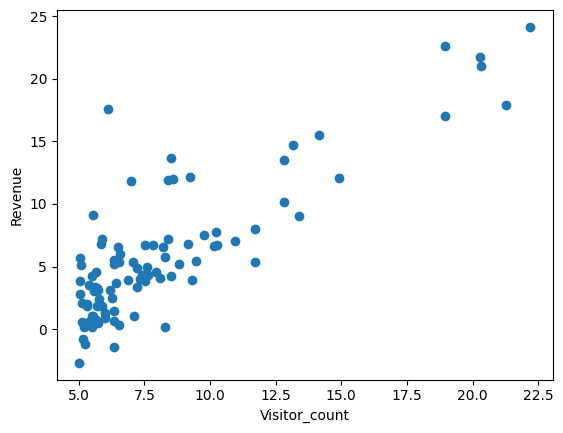

In [55]:
X = data.iloc[:,0].values
# without using values it is series
Y = data.iloc[:,1].values
m = len(Y) #gives no. of trainig set
print(m)
plt.scatter(X,Y)
plt.xlabel('Visitor_count')
plt.ylabel('Revenue')
plt.show

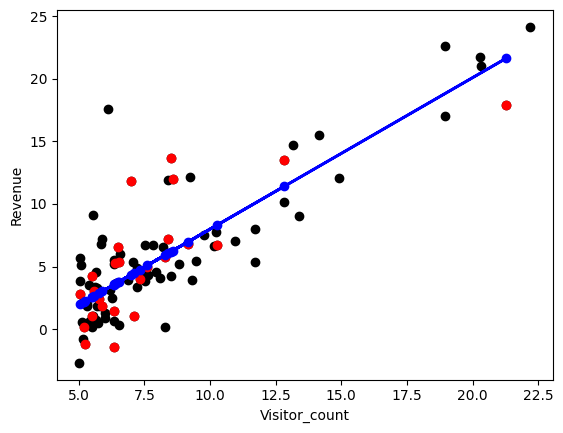

In [56]:
# plotting the orginal data
plt.scatter(X,Y,color="black")
# test data
plt.scatter(X_test,Y_test, color='red')
# 
plt.plot(X_test,y_pred, 'bo-', linewidth = 2)
plt.xlabel('Visitor_count')
plt.ylabel('Revenue')
plt.show()

## Multivariable Regression

![Multi feature Linear regression](img/multi_feature_linear_reg.png)

Location: 

* 0 -> Saket
* 1 -> Chanakyapuri
* ........

Logistic Regression (Classification)

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [61]:
!wget -qq https://cdn.iisc.talentsprint.com/AIandMLOps/Datasets/data3.txt

In [ ]:
data = pd.read_csv('dataset/data3.txt', header = None)
data

,0,1,2
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1
...,...,...,...
95,83.489163,48.380286,1
96,42.261701,87.103851,1
97,99.315009,68.775409,1
98,55.340018,64.931938,1


In [63]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       100 non-null    float64
 1   1       100 non-null    float64
 2   2       100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [64]:
# two label

In [65]:
# taking integer values
for i in range(2):
    data[i] = data[i].astype('int')

In [66]:
data.head()

,0,1,2
0,34,78,0
1,30,43,0
2,35,72,0
3,60,86,1
4,79,75,1


In [67]:
X = data.iloc[:,0:2]

In [68]:
X

,0,1
0,34,78
1,30,43
2,35,72
3,60,86
4,79,75
...,...,...
95,83,48
96,42,87
97,99,68
98,55,64


In [72]:
#  i want to store 2nd index column in y
# Separating data into two group one for Y = 0 and another for all Y = 1 and Plotting

# only match with True rows
data1 = data[data[2]==1]
data2 = data[data[2]==0] 


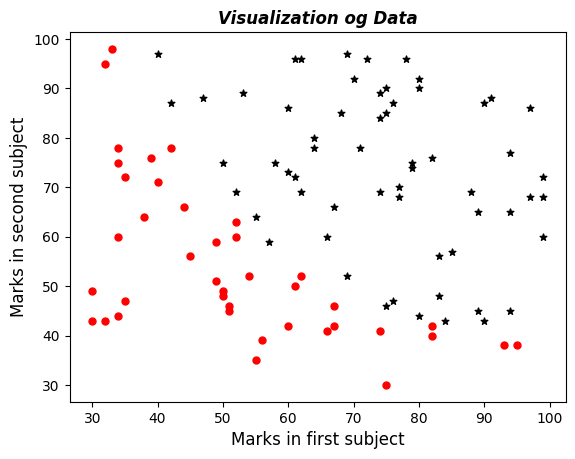

In [73]:
# Plotting
plt.scatter(data1[0],data1[1],color='k', s = 25, marker='*') #All the data with Y = 1, represented by Black, Admitted
plt.scatter(data2[0],data2[1],color='r',s=25,marker='o') #All data with Y= 0, represnted by Red, rejected
plt.title('Visualization og Data',fontsize = 12, style = 'italic', fontweight='bold')
plt.xlabel('Marks in first subject',fontsize = 12)
plt.ylabel('Marks in second subject',fontsize=12)
plt.show()

In [74]:
# we can see the clear pattern , their is almost a straight line like any above the line is eligible (label = 1)


In [75]:
# It can be plotted in another way

In [76]:
X = data.iloc[:,[0,1]]
print(X)
Y = data.iloc[:,2]


     0   1
0   34  78
1   30  43
2   35  72
3   60  86
4   79  75
..  ..  ..
95  83  48
96  42  87
97  99  68
98  55  64
99  74  89

[100 rows x 2 columns]


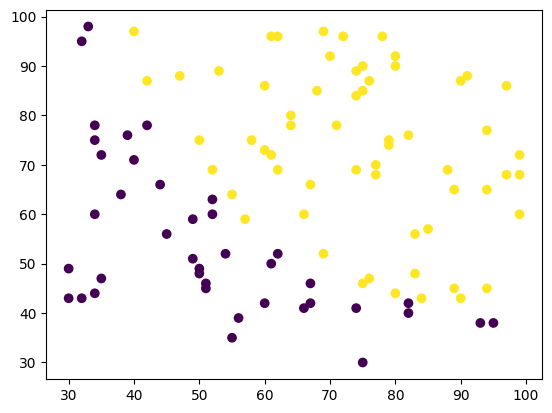

In [77]:
plt.scatter(X[0],X[1],c=Y)

In [79]:
clf = LogisticRegression()
clf.fit(X,Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [80]:
# object of our model is clf

In [82]:
# lets predict
clf.predict([[90,60]])
# we can visualize from the above graph

array([1])

In [ ]:
clf.score(X,Y)
# it is diff from RMSE
# 

0.89

In [84]:
clf.coef_

array([[0.20888649, 0.20344633]])

In [85]:
A = clf.coef_[0,0]
B = clf.coef_[0,1]
A,B

(np.float64(0.20888649493214864), np.float64(0.2034463338007975))

In [86]:
clf.intercept_

array([-25.24386006])

In [87]:
C = clf.intercept_[0]

In [88]:
# AX + BY + C = 0
#  Y = (-C - AX) / B
#  Y = (-clf_intercept_[0] - clf.coef_[0,0]*X[0]) / clf.coef_[0,1]


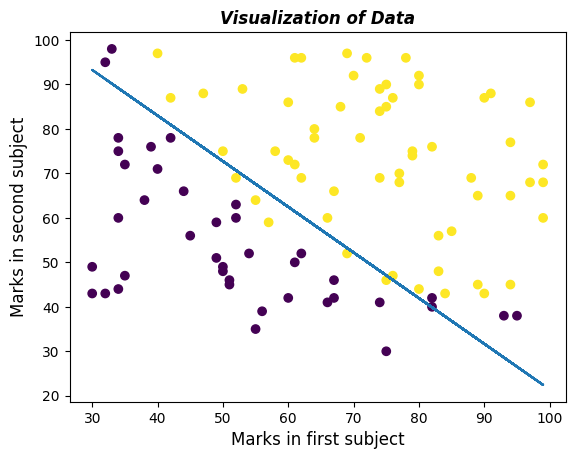

In [ ]:
# plot this Y
Y1 = (-(clf.intercept_[0]) - clf.coef_[0,0]*X[0])/clf.coef_[0,1]
plt.plot(X[0], Y1)
plt.scatter(X[0],X[1],c=Y)
plt.title('Visualization of Data', fontsize = 12, style='italic', fontweight='bold')
plt.xlabel('Marks in first subject',fontsize=12)
plt.ylabel('Marks in second subject',fontsize=12)
plt.show()
# line is the deciding line

In [91]:
# Example 2 -> Diabetes Dataset


In [93]:
!wget -qq https://cdn.iisc.talentsprint.com/AIandMLOps/Datasets/diabetes.csv

In [95]:
diabetes = pd.read_csv("dataset/diabetes.csv")
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [96]:
# Extract features and label
X = diabetes.drop("Outcome",axis=1)
y = diabetes["Outcome"]

In [97]:
# Split the data into train and test data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)
print(X_train.shape)

(576, 8)


In [ ]:
X_train.values.mean(axis=0)
# what have i done???
# mean of pregnancies , Glucose .........

array([  3.74131944, 120.65972222,  69.50520833,  20.49479167,
        80.36284722,  31.98177083,   0.46861806,  32.921875  ])

In [101]:
X_train.values.std(axis=0)

array([  3.30258122,  32.10527674,  18.38383123,  15.41125943,
       116.12260915,   7.61558373,   0.33903031,  11.49754536])

In [102]:
# dont do for the TEST data

In [104]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# scaler object has somewhere stored the mean and SD of train , hence we make sure that we never use test data
# mean and SD of each feature and then transform x - mean/SD

# only transform --> since we only calculate 
X_test_scaled = scaler.transform(X_test) ## ???

In [105]:
# Applying Logistic Regression

LR = LogisticRegression()
# never transform your label, we use transformation only in features
LR.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [106]:
y_pred = LR.predict(X_test_scaled)

In [107]:
print("Accuracy of Logistic Regression is:", accuracy_score(y_test, y_pred))

Accuracy of Logistic Regression is: 0.7291666666666666


In [108]:
# Example of prediction for new sample

In [109]:
sample = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
sample

array([[  6.   , 148.   ,  72.   ,  35.   ,   0.   ,  33.6  ,   0.627,
         50.   ]])

In [ ]:
sample_scaled = scaler.transform(sample)
# we transform using mean and SD we calculated from training dataset, scaler has stored the mean and SD of the training dataset
sample_scaled

/csehome/m25csa019/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 0.6839137 ,  0.85158206,  0.13570575,  0.9412085 , -0.69205168,
         0.21248918,  0.46716161,  1.4853714 ]])

In [112]:
Sample_pred = LR.predict(sample_scaled)
Sample_pred
# this person has diabetes

array([1])

Example dataset API

In [114]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples = 100, noise = 0.15, random_state= 42)
print(X)
print(y)

[[ 1.61383833 -0.49115086]
 [ 0.08984723  0.50439056]
 [ 0.74721047 -0.36911116]
 [-1.10174514  0.23685641]
 [-0.72871455  0.14652347]
 [-0.65891281  0.857088  ]
 [ 0.22828266  0.73453868]
 [ 1.39439184 -0.45063627]
 [ 0.87158283  0.70852888]
 [ 0.88304472 -0.12658445]
 [ 0.38220326  0.76957897]
 [-0.32279169  0.92145523]
 [ 1.29900621 -0.64914275]
 [-0.63569974  0.91873422]
 [ 1.96899387  0.297549  ]
 [ 1.21073294  0.37721455]
 [ 1.13998191 -0.36088456]
 [ 1.06805159 -0.53460667]
 [ 0.49598571  0.66135542]
 [-0.26038715  0.88295876]
 [-0.06516219  0.13092506]
 [ 1.87005845 -0.18659309]
 [ 0.03146515  0.79868048]
 [-1.03151461  0.35788726]
 [ 0.45814234  0.00308109]
 [ 0.40767679  0.9574049 ]
 [-0.9379972   0.46846678]
 [ 2.02675758  0.09006383]
 [ 0.73867736  0.52356398]
 [ 0.71349755 -0.61055519]
 [ 0.92445501  0.79897643]
 [-1.05805492  0.1152524 ]
 [ 1.80904221 -0.49580332]
 [-0.17181754  1.27111359]
 [ 2.22167197 -0.16625369]
 [ 0.8346617   0.34040713]
 [ 0.28332589 -0.45537977]
 